## Bibliotekos

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sb
import regex as re
from functools import reduce

from sklearn.preprocessing import StandardScaler
from missforest import MissForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor

import datetime
import pytz

import haversine as hs   
from haversine import Unit

from scipy.interpolate import make_smoothing_spline
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from skforecast.stats._arima import Arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [82]:
random.seed(123)
np.random.seed(123)

## Duomenys

In [83]:
meteo_data = pd.read_csv("Meteo_nauji.csv", sep = ',')
meteo_data.head(5)

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,snowDepth,conditionCode
0,2017-11-01 00:00:00,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,0.0,cloudy
1,2017-11-01 01:00:00,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,0.0,cloudy
2,2017-11-01 02:00:00,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,0.0,cloudy
3,2017-11-01 03:00:00,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,0.0,cloudy
4,2017-11-01 04:00:00,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,0.0,cloudy


In [84]:
meteo_data.shape

(73028, 12)

### Duomenų tvarkymas ir paruošimas

In [85]:
clean_meteo_data = meteo_data.drop(columns = ['snowDepth', 'conditionCode'])
clean_meteo_data['observationTimeUtc'] = pd.to_datetime(clean_meteo_data['observationTimeUtc'])
clean_meteo_data.shape

(73028, 10)

Paverčiame į Lietuvos laiką

In [86]:
clean_meteo_data['observationTime'] = (clean_meteo_data['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
clean_meteo_data['observationTime'] = clean_meteo_data['observationTime'].dt.tz_localize(None)
clean_meteo_data = clean_meteo_data.drop(columns = ['observationTimeUtc'])
clean_meteo_data.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,2017-11-01 02:00:00
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,2017-11-01 03:00:00
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,2017-11-01 04:00:00
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,2017-11-01 05:00:00
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,2017-11-01 06:00:00


Apkarpome pagal nustatyta nagrinėjama intervalą

In [87]:
clean_meteo_data = clean_meteo_data[(clean_meteo_data["observationTime"].dt.date >= datetime.date(2018,7,1)) & (clean_meteo_data["observationTime"].dt.date <= datetime.date(2026,1,31))].sort_values(by='observationTime')
clean_meteo_data.shape

(66529, 10)

Praleistų reikšmių analizė

In [88]:
clean_meteo_data.isnull().sum()

airTemperature            58
feelsLikeTemperature      93
windSpeed                 92
windGust                 134
windDirection             87
cloudCover              1510
seaLevelPressure          68
relativeHumidity          71
precipitation             21
observationTime            0
dtype: int64

In [89]:
(clean_meteo_data.isnull().sum() / len(clean_meteo_data)) * 100

airTemperature          0.087180
feelsLikeTemperature    0.139789
windSpeed               0.138286
windGust                0.201416
windDirection           0.130770
cloudCover              2.269687
seaLevelPressure        0.102211
relativeHumidity        0.106720
precipitation           0.031565
observationTime         0.000000
dtype: float64

In [90]:
station_year = clean_meteo_data["observationTime"].dt.year.unique()
station_year.sort()
nan_year_result = []
for year in station_year:
    nan_year_result.append(clean_meteo_data[clean_meteo_data["observationTime"].dt.year == year].isnull().sum())
nan_year_Vilnius = pd.DataFrame(nan_year_result, index = station_year)
nan_year_Vilnius

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
2018,0,2,2,5,0,125,1,0,0,0
2019,0,1,1,5,0,130,0,0,3,0
2020,15,20,19,38,18,307,17,18,0,0
2021,0,0,0,1,0,147,0,0,0,0
2022,0,0,0,1,0,272,0,0,0,0
2023,0,0,0,0,0,111,0,0,0,0
2024,32,49,49,53,48,151,32,32,0,0
2025,11,21,21,30,21,263,18,21,18,0
2026,0,0,0,1,0,4,0,0,0,0


In [91]:
clean_meteo_data.groupby(clean_meteo_data['observationTime'].dt.year)['observationTime'].apply(lambda x: x.dt.date.nunique())

observationTime
2018    184
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
2026     31
Name: observationTime, dtype: int64

Praleisti stebėjimai pagal kritulius

In [92]:
pd.set_option('display.max_rows', 500)
clean_meteo_data[clean_meteo_data['precipitation'].isnull()]

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
10688,-1.7,NaN,NaN,NaN,237.0,100.0,1013.6,92.0,NaN,2019-01-20 14:00:00
10997,1.1,-3.6,5.0,9.0,123.0,100.0,1008.3,96.0,NaN,2019-02-02 11:00:00
10998,1.4,-3.2,5.1,9.5,138.0,100.0,1008.0,94.0,NaN,2019-02-02 12:00:00
71076,7.5,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 18:00:00
71077,8.0,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 19:00:00
71078,8.5,NaN,NaN,NaN,NaN,NaN,1014.4,NaN,NaN,2025-12-10 20:00:00
71079,8.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-10 21:00:00
71082,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-11 00:00:00
71492,0.8,-4.6,6.3,NaN,306.0,100.0,1001.7,91.0,NaN,2025-12-28 02:00:00
71516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-29 02:00:00


## Praleistų kritulių reikšmių įrašymas

Kaimyninių stočių atrinkimas pagal atstumą

In [93]:
stations = pd.read_csv("Stotys.csv", sep = ',')
stations.head()

,Stotis,Platuma,Ilguma
0,akmenes-ams,56.249920,22.730810
1,alytaus-ams,54.412435,24.063274
2,anyksciu-ams,55.517350,25.117800
3,birstono-ams,54.603217,24.035802
4,birzu-ams,56.193191,24.774184


In [94]:
Vilnius_index = stations[stations['Stotis'] == 'vilniaus-ams'].index
stations_without_Vilnius = stations.drop(Vilnius_index)

In [95]:
Vilnius_coordinates = (54.6872, 25.2797)
stations_distances = []

for i in range(len(stations_without_Vilnius)):
    station_coords = (stations_without_Vilnius['Platuma'].iloc[i], stations_without_Vilnius['Ilguma'].iloc[i])

    distance = hs.haversine(station_coords, Vilnius_coordinates, unit=Unit.KILOMETERS)
    stations_distances.append(distance)

stations_without_Vilnius['Atstumas_iki_Vilniaus'] = stations_distances

In [96]:
stations_without_Vilnius.sort_values('Atstumas_iki_Vilniaus').head()

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus
44,traku-ams,54.615924,24.785292,32.778577
8,elektrenu-ams,54.786161,24.689854,39.432578
36,salcininku-ams,54.310380,25.374422,42.344600
12,kaisiadoriu-ams,54.856942,24.437842,57.200637
25,moletu-ams,55.235244,25.416378,61.561275


In [97]:
ams_dates_data = {
    'akmenes-ams': '2014-07-31', 'alytaus-ams': '2014-07-31', 'anyksciu-ams': '2022-11-10',
    'birstono-ams': '2021-07-03', 'birzu-ams': '2013-10-11', 'dotnuvos-ams': '2013-10-11',
    'druskininku-ams': '2021-07-03', 'duksto-ams': '2013-10-11', 'elektrenu-ams': '2020-10-28',
    'jonavos-ams': '2021-09-05', 'joniskio-ams': '2020-11-14', 'jurbarko-ams': '2020-10-28',
    'kaisiadoriu-ams': '2020-10-17', 'kalvarijos-ams': '2021-07-18', 'kauno-ams': '2013-10-11',
    'kazlu-rudos-ams': '2021-07-18', 'kelmes-ams': '2021-08-07', 'klaipedos-ams': '2013-10-11',
    'kretingos-ams': '2021-07-17', 'kupiskio-ams': '2020-11-13', 'kybartu-ams': '2013-10-11',
    'laukuvos-ams': '2013-10-11', 'lazdiju-ams': '2013-10-11', 'marijampoles-ams': '2014-07-31',
    'mazeikiu-ams': '2014-07-31', 'moletu-ams': '2020-11-06', 'nidos-ams': '2013-10-11',
    'pagegiu-ams': '2021-07-11', 'pakruojo-ams': '2020-11-14', 'panevezio-ams': '2013-10-11',
    'plunges-ams': '2021-08-07', 'prienu-ams': '2021-07-04', 'raseiniu-ams': '2013-10-11',
    'rietavo-ams': '2021-08-06', 'rokiskio-ams': '2014-07-31', 'sakiu-ams': '2020-10-29',
    'salcininku-ams': '2020-10-23', 'seduvos-ams': '2014-07-31', 'siauliu-ams': '2013-10-11',
    'silutes-ams': '2013-10-11', 'skuodo-ams': '2021-08-06', 'svencioniu-ams': '2014-07-31',
    'taurages-ams': '2014-07-31', 'telsiu-ams': '2013-10-11', 'traku-ams': '2020-10-18',
    'ukmerges-ams': '2013-10-11', 'utenos-ams': '2013-10-11', 'varenos-ams': '2013-10-11',
    'ventes-ams': '2020-11-02', 'vezaiciu-ams': '2014-07-31', 'vilniaus-ams': '2013-10-11',
    'zarasu-ams': '2020-11-06'
}

stations_without_Vilnius['Data'] = stations_without_Vilnius['Stotis'].map(ams_dates_data)
stations_without_Vilnius['Data'] = pd.to_datetime(stations_without_Vilnius['Data'])
stations_without_Vilnius.sort_values('Atstumas_iki_Vilniaus').head()

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus,Data
44,traku-ams,54.615924,24.785292,32.778577,2020-10-18
8,elektrenu-ams,54.786161,24.689854,39.432578,2020-10-28
36,salcininku-ams,54.310380,25.374422,42.344600,2020-10-23
12,kaisiadoriu-ams,54.856942,24.437842,57.200637,2020-10-17
25,moletu-ams,55.235244,25.416378,61.561275,2020-11-06


In [98]:
stations_without_Vilnius[stations_without_Vilnius['Data'] < '2017-01-01'].sort_values('Atstumas_iki_Vilniaus').head(10)

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus,Data
47,varenos-ams,54.248271,24.551760,67.785494,2013-10-11
45,ukmerges-ams,55.264145,24.760335,72.209127,2013-10-11
41,svencioniu-ams,55.132777,26.172895,75.593977,2014-07-31
1,alytaus-ams,54.412435,24.063274,84.188443,2014-07-31
46,utenos-ams,55.515321,25.589692,94.170826,2013-10-11
14,kauno-ams,54.883960,23.835880,95.125018,2013-10-11
7,duksto-ams,55.517856,26.316140,113.480953,2013-10-11
5,dotnuvos-ams,55.395993,23.866224,119.669700,2013-10-11
22,lazdiju-ams,54.232210,23.510680,125.028855,2013-10-11
23,marijampoles-ams,54.528855,23.351810,125.395242,2014-07-31


Atrinktos pirmos 3 stotys, atrinktos pagal atstumą iki Vilniaus, nedaugiau kaip 80 km., ir stebėjimų pradžios laiką.

Sujungiami kaimyninių stočių duomenys

In [99]:
def clean_file(file_name):
    file = pd.read_csv(file_name, sep = ',')
    if 'snowDepth' in file:
        file = file.drop(columns=['snowDepth'])

    file['observationTimeUtc'] = pd.to_datetime(file['observationTimeUtc'])
    
    if file_name != 'Meteo_nauji.csv':
        name = re.match(r'([^_]+)', file_name).group(0)
        file = file.rename(columns = {
            'airTemperature' : f'{name}_airTemperature',
            'feelsLikeTemperature' : f'{name}_feelsLikeTemperature',
            'windSpeed' : f'{name}_windSpeed',
            'windGust' : f'{name}_windGust',
            'windDirection' : f'{name}_windDirection',
            'cloudCover' : f'{name}_cloudCover',
            'seaLevelPressure' : f'{name}_seaLevelPressure',
            'relativeHumidity' : f'{name}_relativeHumidity',
            'precipitation' : f'{name}_precipitation',
            'conditionCode' : f'{name}_conditionCode'
        })
    return file

all_meteo_stations_files = ['Meteo_nauji.csv', 'Varenos_meteo_2017_2026.csv', 'Ukmerges_meteo_2017_2026.csv', 'Svencioniu_meteo_2017_2026.csv', 'Alytaus_meteo_2017_2026.csv', 'Utenos_meteo_2017_2026.csv', 'Kauno_meteo_2017_2026.csv']
all_dfs = [clean_file(f) for f in all_meteo_stations_files]
all_stations_meteo_merged = reduce(lambda  left, right: pd.merge(left, right, on='observationTimeUtc', how='outer'), all_dfs)

files = ['Meteo_nauji.csv', 'Varenos_meteo_2017_2026.csv', 'Ukmerges_meteo_2017_2026.csv', 'Svencioniu_meteo_2017_2026.csv']
all_dfs = [clean_file(f) for f in files]
meteo_merged = reduce(lambda  left, right: pd.merge(left, right, on='observationTimeUtc', how='outer'), all_dfs)

In [100]:
all_stations_meteo_merged['observationTime'] = (all_stations_meteo_merged['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
all_stations_meteo_merged['observationTime'] = all_stations_meteo_merged['observationTime'].dt.tz_localize(None)
all_stations_meteo_merged = all_stations_meteo_merged.drop(columns = ['observationTimeUtc'])

meteo_merged['observationTime'] = (meteo_merged['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
meteo_merged['observationTime'] = meteo_merged['observationTime'].dt.tz_localize(None)
meteo_merged = meteo_merged.drop(columns = ['observationTimeUtc'])
meteo_merged.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode,...,Svencioniu_feelsLikeTemperature,Svencioniu_windSpeed,Svencioniu_windGust,Svencioniu_windDirection,Svencioniu_cloudCover,Svencioniu_seaLevelPressure,Svencioniu_relativeHumidity,Svencioniu_precipitation,Svencioniu_conditionCode,observationTime
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,cloudy,...,-2.0,0.3,4.5,272.0,NaN,1011.2,93.0,0.0,NaN,2017-11-01 02:00:00
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,cloudy,...,-1.7,0.7,5.2,250.0,NaN,1011.4,93.0,0.0,NaN,2017-11-01 03:00:00
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,cloudy,...,-1.5,0.3,3.2,228.0,NaN,1011.4,93.0,0.0,NaN,2017-11-01 04:00:00
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,cloudy,...,-1.1,0.2,4.2,220.0,NaN,1011.4,93.0,0.0,NaN,2017-11-01 05:00:00
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,cloudy,...,-0.9,0.8,4.5,226.0,NaN,1011.1,94.0,0.0,NaN,2017-11-01 06:00:00


In [101]:
meteo_merged.shape

(73032, 41)

Praleistos reikšmės sujungtąjame rinkinyje

In [102]:
meteo_merged.isnull().sum()

airTemperature                        62
feelsLikeTemperature                  97
windSpeed                             96
windGust                             142
windDirection                         91
cloudCover                          1609
seaLevelPressure                      72
relativeHumidity                      75
precipitation                         26
conditionCode                        408
Varenos_airTemperature                 7
Varenos_feelsLikeTemperature         389
Varenos_windSpeed                    273
Varenos_windGust                     339
Varenos_windDirection                273
Varenos_cloudCover                  1128
Varenos_seaLevelPressure               7
Varenos_relativeHumidity             124
Varenos_precipitation                  7
Varenos_conditionCode                130
Ukmerges_airTemperature                9
Ukmerges_feelsLikeTemperature       1439
Ukmerges_windSpeed                    37
Ukmerges_windGust                     49
Ukmerges_windDir

Pašalinami stulpeliai turintis visus praleistus stebėjimus

In [103]:
meteo_merged = meteo_merged.dropna(axis=1, how='all')
meteo_merged.shape

(73032, 39)

Kritulių koreliacija tarp atrinktų kaimyninių stočių

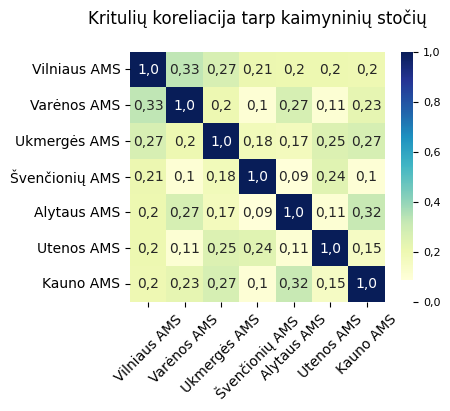

In [104]:
all_stations_precipitation = all_stations_meteo_merged[['observationTime', 'precipitation', 'Varenos_precipitation', 'Ukmerges_precipitation', 'Svencioniu_precipitation', 'Alytaus_precipitation', 'Utenos_precipitation', 'Kauno_precipitation']]

col_names = {
    'precipitation': 'Vilniaus AMS',
    'Varenos_precipitation': 'Varėnos AMS',
    'Ukmerges_precipitation': 'Ukmergės AMS',
    'Svencioniu_precipitation': 'Švenčionių AMS',
    'Alytaus_precipitation': 'Alytaus AMS',
    'Utenos_precipitation': 'Utenos AMS',
    'Kauno_precipitation': 'Kauno AMS'
}

width_inch = 11.9 / 2.54
height_inch = width_inch * 0.9

plt.figure(figsize=(width_inch, height_inch))

precipitation_corr = all_stations_precipitation.rename(columns=col_names).corr(numeric_only=True)
annot_labels = precipitation_corr.round(2).astype(str).apply(lambda x: x.str.replace('.', ','))

ax = sb.heatmap(precipitation_corr, cmap="YlGnBu", annot=annot_labels, fmt="", annot_kws={"size": 10})
colorbar = ax.collections[0].colorbar
colorbar.set_ticks(colorbar.get_ticks())
colorbar.set_ticklabels([str(round(t, 1)).replace('.', ',') for t in colorbar.get_ticks()], size=8)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.title("Kritulių koreliacija tarp kaimyninių stočių", pad=20, fontsize=12)

plt.savefig("stations_heatmap.png", dpi=300, bbox_inches='tight')

plt.tight_layout() 
plt.show()

### Kritulių praleistų reikšmių testavimo aibė - block bootstrap metodas

Pirmasis praleistų reikšmių blokas sukūriapmas po 20 % pradinių stebėjimų, kiti blokai paskirstomi po likusį intervalą. Vienas blokas - 12 valandų tarpas. Bendrai pašalinama 10 % stebėjimų.

In [105]:
def block_bootstrapping_testdata(data_column, data_skip = 0.2, p_remove = 0.1, block_size = 12):

    data_array = np.array(data_column, dtype=float)
    N = len(data_array)
    total_to_remove = N * p_remove
    blocks_count =  int(total_to_remove // block_size)
    position = int(N * data_skip)

    step = int((N - position) / blocks_count)
    for block in range(blocks_count):
        if position + block_size < N:
            data_array[position : position + block_size] = np.nan
            position += int(step + random.randint(-10, 10))
        else:
            break
    return data_array


In [106]:
data_test_copy1 = meteo_merged.copy()
data_test_copy1['test_precipitation'] = data_test_copy1['precipitation']
data_test_copy1['test_precipitation'] = block_bootstrapping_testdata(data_test_copy1['test_precipitation'])

### Praleistų reikšmių įrašymo metodų išbandymas

Skaitinių stulpelių parinkimas

In [107]:
numeric_data = data_test_copy1.select_dtypes(include='number')
numeric_data = numeric_data.drop(columns=['precipitation'])

Duomenų paruošimas

In [108]:
scaler = StandardScaler()
numeric_data_scaled = pd.DataFrame(scaler.fit_transform(numeric_data), columns=numeric_data.columns, index=numeric_data.index)

Missforest metodas:

In [109]:
mf = MissForest()
miss_forest_data = mf.fit_transform(x=numeric_data_scaled)
missforest_true_data = pd.DataFrame(scaler.inverse_transform(miss_forest_data), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['missforest_precipitation'] = missforest_true_data['test_precipitation']
data_test_copy1['missforest_precipitation'] = data_test_copy1['missforest_precipitation'].clip(lower=0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [02:11<00:00, 26.33s/it]
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

XGBoost motodas:

In [110]:
xgb = IterativeImputer(estimator=XGBRegressor(n_estimators=100, random_state=123), max_iter=10, random_state=123)
xgb_transformed = xgb.fit_transform(numeric_data_scaled)
imputed_df_xgb = pd.DataFrame(scaler.inverse_transform(xgb_transformed), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['xgb_precipitation'] = imputed_df_xgb['test_precipitation']
data_test_copy1['xgb_precipitation'] = data_test_copy1['xgb_precipitation'].clip(lower=0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MICE metodas:

In [111]:
imputer = IterativeImputer(random_state=123)
imputed_data = imputer.fit_transform(numeric_data_scaled)
meteo_imputed_mice = pd.DataFrame(scaler.inverse_transform(imputed_data), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['mice_precipitation'] = meteo_imputed_mice['test_precipitation']
data_test_copy1['mice_precipitation'] = data_test_copy1['mice_precipitation'].clip(lower=0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


SARIMA modelis:

Duomenų paruošimas

In [112]:
y_precipitation = data_test_copy1['precipitation'].values
x_time_number = np.arange(len(y_precipitation))

mask = ~np.isnan(y_precipitation)
x_train = x_time_number[mask]
y_train = y_precipitation[mask]

spl = make_smoothing_spline(x_train, y_train, lam=None)
clean_precipitation_series = spl(x_time_number)

clean_precipitation_series_2d = clean_precipitation_series.reshape(-1, 1)
clean_precipitation_series_scaled = scaler.fit_transform(clean_precipitation_series_2d)

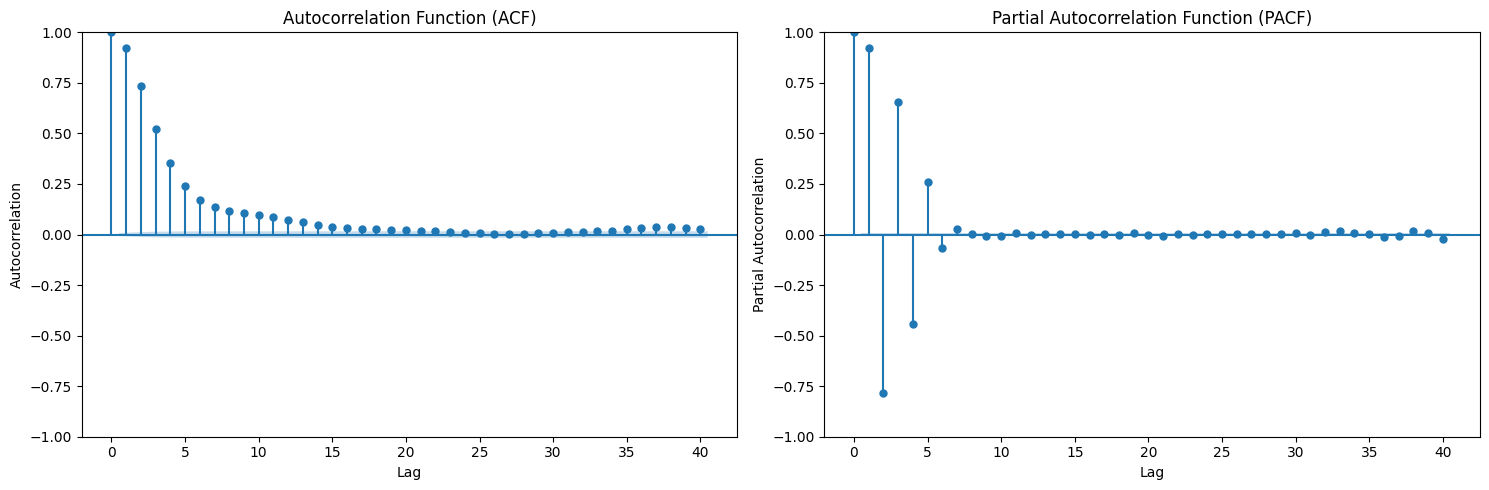

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(clean_precipitation_series, lags=40, ax=ax[0])
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("Autocorrelation")
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(clean_precipitation_series, lags=40, ax=ax[1])
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("Partial Autocorrelation")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [114]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistika: {result[0]}')
    print(f'p-reikšmė: {p_value}')
    print('Stacionari laiko eilutė' if p_value < 0.05 else 'Nestacionari laiko eilutė')


check_stationarity(clean_precipitation_series_scaled)

ADF Statistika: -33.42319420254954
p-reikšmė: 0.0
Stacionari laiko eilutė


In [115]:
model_auto = Arima(
    order = None,  
    seasonal_order = None,
    seasonal = False,
    ic = "aic",
    stepwise = True,
    trace = True
)

model_auto.fit(y=clean_precipitation_series_scaled, suppress_warnings=True)

print("-" * 30)
print(f"Geriausi parinkti parametrai: {model_auto.best_params_}")


Fitting models using approximations...

 ARIMA(p,d,q)(P,D,Q)[m]                     : aic
 ------------------------------------------------
 ARIMA(2,0,2) with non-zero mean : -58840.0523
 ARIMA(0,0,0) with non-zero mean : 207259.8379
 ARIMA(1,0,0) with non-zero mean : 68163.0089
 ARIMA(0,0,1) with non-zero mean : 112123.5472
 ARIMA(0,0,0) with zero mean     : 207257.8379
 ARIMA(1,0,2) with non-zero mean : -48532.6123
 ARIMA(2,0,1) with non-zero mean : -49464.7715
 ARIMA(3,0,2) with non-zero mean : -64045.8915
 ARIMA(3,0,2) with zero mean     : -64047.8915
 ARIMA(2,0,2) with zero mean     : -61964.4969
 ARIMA(3,0,1) with zero mean     : -62226.8620
 ARIMA(4,0,2) with zero mean     : -64120.5132
 ARIMA(4,0,2) with non-zero mean : -64117.3329
 ARIMA(4,0,1) with zero mean     : -63846.7211
 ARIMA(5,0,2) with zero mean     : -63919.7438
 ARIMA(4,0,3) with zero mean     : -64159.2725
 ARIMA(4,0,3) with non-zero mean : -64157.2690
 ARIMA(3,0,3) with zero mean     : -64157.6900
 ARIMA(5,0,3) 

In [116]:
model = ARIMA(scaler.fit_transform(data_test_copy1[['test_precipitation']]), 
              order=(5, 0, 3))

model_results = model.fit()
data_test_copy1['arima_precipitation'] = data_test_copy1['test_precipitation'].fillna(pd.Series(scaler.inverse_transform(model_results.fittedvalues.reshape(-1, 1)).flatten(), index=data_test_copy1.index))
data_test_copy1['arima_precipitation'] = data_test_copy1['arima_precipitation'].clip(lower=0)

In [117]:
data_test_copy1['arima_precipitation'].isnull().sum()

np.int64(0)

Įrašymo meotdų palyginimas:

In [118]:
# pd.set_option('display.max_rows', 600)
# data_first_block[data_first_block['test_precipitation'].isnull()]

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')
C:\Users\eveli\AppData\Local\Temp\ipykernel_15344\1697385758.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels)


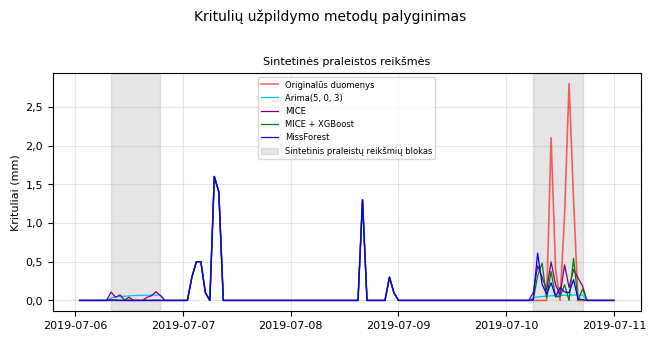

In [119]:
start = int(len(data_test_copy1) * 0.2)
data_first_block = data_test_copy1[start + 80 : start + 200]

width_inch = 17 / 2.54
height_inch = width_inch * 0.5

fig, ax1 = plt.subplots(figsize=(width_inch, height_inch))
ax1.plot(data_first_block['observationTime'], data_first_block['precipitation'], label='Originalūs duomenys', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(data_first_block['observationTime'], data_first_block['arima_precipitation'], label='Arima(5, 0, 3)', color='deepskyblue', linewidth=0.9)
ax1.plot(data_first_block['observationTime'], data_first_block['mice_precipitation'], label='MICE', color='purple', linewidth=0.9)
ax1.plot(data_first_block['observationTime'], data_first_block['xgb_precipitation'], label='MICE + XGBoost', color='green', linewidth=0.9)
ax1.plot(data_first_block['observationTime'], data_first_block['missforest_precipitation'], label='MissForest', color='blue', linewidth=0.9)
# ax1.axvspan('2019-07-02 17:00:00', '2019-07-03 04:00:00', 
#             color='gray', alpha=0.2, label='Sintetinis praleistų reikšmių blokas')
ax1.axvspan('2019-07-06 08:00:00', '2019-07-06 19:00:00', 
            color='gray', alpha=0.2, label='Sintetinis praleistų reikšmių blokas')
ax1.axvspan('2019-07-10 06:00:00', '2019-07-10 17:00:00	', 
            color='gray', alpha=0.2)
ax1.set_title('Sintetinės praleistos reikšmės', fontsize=8)
ax1.set_ylabel('Krituliai (mm)', fontsize=8)
ax1.legend(fontsize=6)
ax1.tick_params(axis='both', labelsize=8)
# ax1.tick_params(axis='x', rotation=45)
labels = [str(tick).replace('.', ',') for tick in ax1.get_yticks()]
ax1.set_yticklabels(labels)
ax1.grid(True, alpha=0.3)
fig.suptitle('Kritulių užpildymo metodų palyginimas', fontsize=10, y=1.005)

plt.savefig("algorithms_comparison_precipitation.png", dpi=300, bbox_inches='tight')

plt.tight_layout() 
plt.show()

Metrikų skaičiavimas

In [120]:
synthetic_nan = data_test_copy1['test_precipitation'].isna() & data_test_copy1['precipitation'].notna()
precipitation_true = data_test_copy1.loc[synthetic_nan, 'precipitation']
precipitation_arima = data_test_copy1.loc[synthetic_nan, 'arima_precipitation']
precipitation_mf = data_test_copy1.loc[synthetic_nan, 'missforest_precipitation']
precipitation_xgb = data_test_copy1.loc[synthetic_nan, 'xgb_precipitation']
precipitation_mice = data_test_copy1.loc[synthetic_nan, 'mice_precipitation']

# precipitation_arima = precipitation_arima.clip(lower=0)
# precipitation_mf = precipitation_mf.clip(lower=0)
# precipitation_xgb = precipitation_xgb.clip(lower=0)
# precipitation_mice = precipitation_mice.clip(lower=0)

results = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R^2'],
    'Arima(5, 0, 3)': [
        mean_absolute_error(precipitation_true, precipitation_arima),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_arima)),
        r2_score(precipitation_true, precipitation_arima)
    ],
    'MissForest': [
        mean_absolute_error(precipitation_true, precipitation_mf),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_mf)),
        r2_score(precipitation_true, precipitation_mf)
    ],
    'MICE': [
        mean_absolute_error(precipitation_true, precipitation_mice),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_mice)),
        r2_score(precipitation_true, precipitation_mice)
    ],
    'MICE + XGBoost': [
        mean_absolute_error(precipitation_true, precipitation_xgb),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_xgb)),
        r2_score(precipitation_true, precipitation_xgb)
    ]
})

print(results.round(4))

  Metrika  Arima(5, 0, 3)  MissForest    MICE  MICE + XGBoost
0     MAE          0.1207      0.0689  0.1052          0.0719
1    RMSE          0.4271      0.3776  0.3473          0.3309
2     R^2          0.0717      0.2747  0.3861          0.4429


Toliau dirbsime su XGBoost praleistų kritulių užpildytomis reikšmėmis

In [121]:
numeric_data = meteo_merged.select_dtypes(include='number')
numeric_data_scaled = pd.DataFrame(scaler.fit_transform(numeric_data), columns=numeric_data.columns, index=numeric_data.index)

xgb = IterativeImputer(estimator=XGBRegressor(n_estimators=100, random_state=123), max_iter=10, random_state=123)
xgb_transformed = xgb.fit_transform(numeric_data_scaled)
imputed_df_xgb = pd.DataFrame(scaler.inverse_transform(xgb_transformed), columns=numeric_data.columns, index=numeric_data.index)
meteo_merged['xgb_precipitation'] = imputed_df_xgb['precipitation']
meteo_merged['xgb_precipitation'] = meteo_merged['xgb_precipitation'].clip(lower=0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


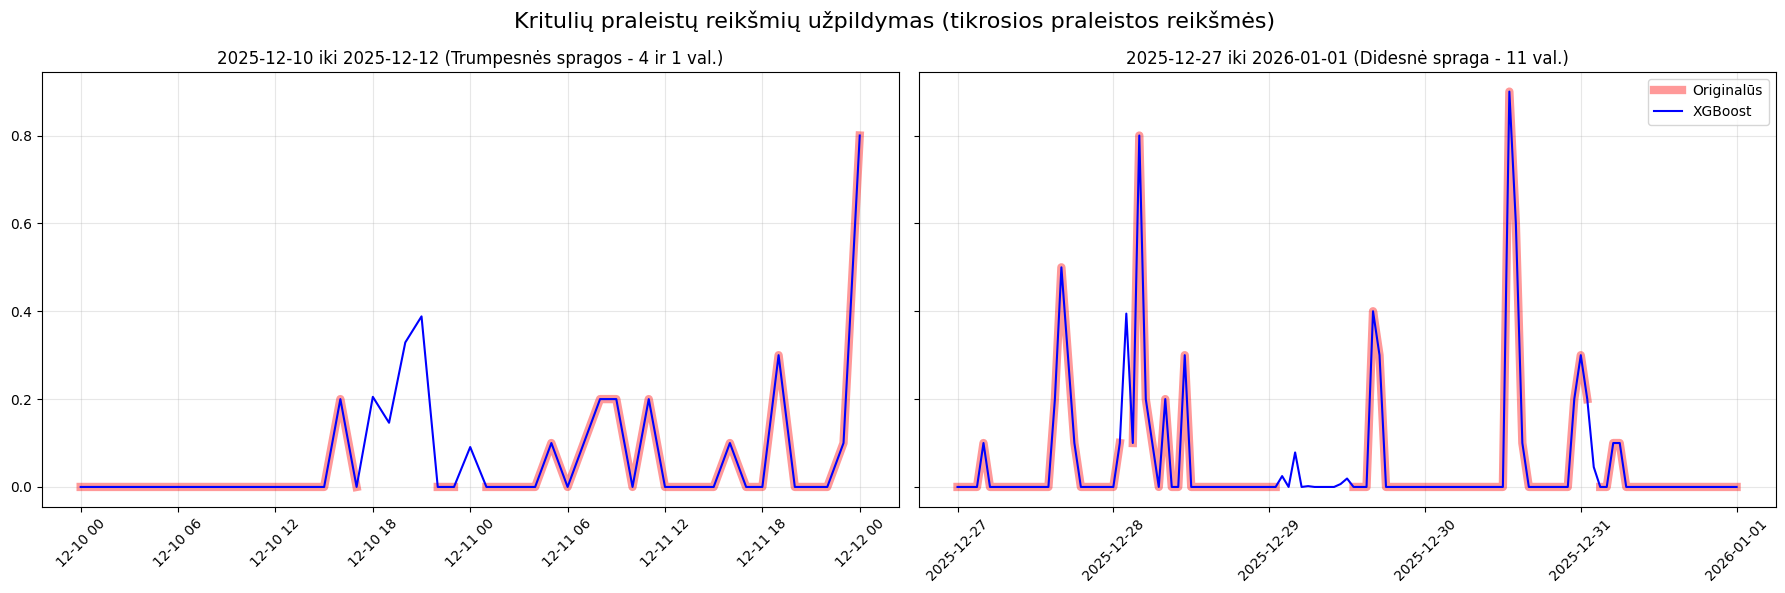

In [122]:
time_mask1 = (meteo_merged['observationTime'] >= '2025-12-10') & (meteo_merged['observationTime'] <= '2025-12-12')
time_mask2 = (meteo_merged['observationTime'] >= '2025-12-27') & (meteo_merged['observationTime'] <= '2026-01-01')
filtered_data1 = meteo_merged[time_mask1]
filtered_data2 = meteo_merged[time_mask2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

ax1.plot(filtered_data1['observationTime'], filtered_data1['precipitation'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax1.plot(filtered_data1['observationTime'], filtered_data1['xgb_precipitation'], label='XGBoost', color='blue', linewidth=1.5)
ax1.set_title('2025-12-10 iki 2025-12-12 (Trumpesnės spragos - 4 ir 1 val.)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.plot(filtered_data2['observationTime'], filtered_data2['precipitation'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax2.plot(filtered_data2['observationTime'], filtered_data2['xgb_precipitation'], label='XGBoost', color='blue', linewidth=1.5)
ax2.set_title('2025-12-27 iki 2026-01-01 (Didesnė spraga - 11 val.)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Kritulių praleistų reikšmių užpildymas (tikrosios praleistos reikšmės)', fontsize=16)
plt.tight_layout()
plt.show()

In [123]:
meteo_merged = meteo_merged.drop(columns = ['precipitation'])
meteo_merged.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,conditionCode,Varenos_airTemperature,...,Svencioniu_airTemperature,Svencioniu_feelsLikeTemperature,Svencioniu_windSpeed,Svencioniu_windGust,Svencioniu_windDirection,Svencioniu_seaLevelPressure,Svencioniu_relativeHumidity,Svencioniu_precipitation,observationTime,xgb_precipitation
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,cloudy,1.7,...,-2.0,-2.0,0.3,4.5,272.0,1011.2,93.0,0.0,2017-11-01 02:00:00,0.0
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,cloudy,1.4,...,-1.7,-1.7,0.7,5.2,250.0,1011.4,93.0,0.0,2017-11-01 03:00:00,0.0
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,cloudy,1.6,...,-1.5,-1.5,0.3,3.2,228.0,1011.4,93.0,0.0,2017-11-01 04:00:00,0.0
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,cloudy,1.9,...,-1.1,-1.1,0.2,4.2,220.0,1011.4,93.0,0.0,2017-11-01 05:00:00,0.0
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,cloudy,1.9,...,-0.9,-0.9,0.8,4.5,226.0,1011.1,94.0,0.0,2017-11-01 06:00:00,0.0


## Duomenų aibės agregavimas

In [124]:
agg_logic = {
    'airTemperature': 'mean',
    'feelsLikeTemperature': 'mean',
    'windSpeed': 'mean',
    'windGust': 'max',
    'windDirection': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cloudCover': 'mean',
    'seaLevelPressure': 'mean',
    'relativeHumidity': 'mean',
    'xgb_precipitation': 'sum'
}

agg_meteo_data = meteo_merged.groupby(meteo_merged["observationTime"].dt.date).agg(agg_logic)
agg_meteo_data = agg_meteo_data.reset_index()
agg_meteo_data["observationTime"] = pd.to_datetime(agg_meteo_data["observationTime"])
agg_meteo_data

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation
0,2017-11-01,4.145455,2.100000,2.800000,10.0,252.0,96.181818,1008.427273,93.954545,7.0
1,2017-11-02,8.333333,6.750000,2.766667,9.3,242.0,94.000000,1000.604167,95.500000,11.7
2,2017-11-03,7.320833,5.770833,2.520833,8.3,294.0,96.000000,1009.004167,94.708333,2.1
3,2017-11-04,6.191667,4.175000,2.775000,7.1,210.0,94.500000,1017.487500,93.166667,0.0
4,2017-11-05,6.229167,3.475000,3.825000,9.5,157.0,72.708333,1015.329167,87.708333,0.0
...,...,...,...,...,...,...,...,...,...,...
3039,2026-02-26,-2.091667,-5.054167,2.904167,8.5,164.0,74.625000,1029.875000,77.875000,0.0
3040,2026-02-27,-0.079167,-4.491667,4.170833,9.4,169.0,73.125000,1023.645833,75.958333,0.0
3041,2026-02-28,3.412500,0.800000,2.758333,5.3,161.0,15.208333,1021.220833,75.375000,0.0
3042,2026-03-01,3.387500,0.379167,3.341667,12.6,160.0,50.625000,1020.195833,81.916667,0.0


In [125]:
agg_meteo_data.isnull().sum()

observationTime          0
airTemperature           0
feelsLikeTemperature     1
windSpeed                1
windGust                 1
windDirection            1
cloudCover              10
seaLevelPressure         0
relativeHumidity         0
xgb_precipitation        0
dtype: int64

### Galutinės duomenų aibės apkarpymas

In [126]:
agg_meteo_data['observationTime'] = pd.to_datetime(agg_meteo_data['observationTime'])
final_agg_meteo_data = agg_meteo_data[(agg_meteo_data["observationTime"].dt.date >= datetime.date(2018,7,1)) & (agg_meteo_data["observationTime"].dt.date <= datetime.date(2026,1,31))].sort_values(by='observationTime')
final_agg_meteo_data.shape

(2772, 10)

In [127]:
final_agg_meteo_data.head(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation
242,2018-07-01,11.295833,10.933333,3.762500,13.9,356.0,89.375000,1010.637500,72.791667,9.1
243,2018-07-02,10.866667,10.429167,2.516667,7.0,327.0,91.500000,1006.662500,94.000000,11.9
244,2018-07-03,13.387500,13.387500,2.537500,8.3,271.0,89.375000,1008.454167,90.041667,10.0
245,2018-07-04,13.591667,13.591667,2.358333,8.7,288.0,88.333333,1009.237500,88.291667,13.9
246,2018-07-05,16.291667,16.291667,1.283333,6.1,293.0,66.000000,1008.079167,70.208333,0.0


In [128]:
final_agg_meteo_data.tail(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation
3009,2026-01-27,-2.200000,-4.162500,1.600000,4.6,70.0,100.000000,1005.416667,95.625000,3.8
3010,2026-01-28,-5.012500,-8.941667,2.495833,7.5,33.0,100.000000,1002.875000,91.916667,6.0
3011,2026-01-29,-9.604167,-14.795833,2.812500,8.3,35.0,81.291667,1009.787500,87.000000,0.0
3012,2026-01-30,-13.600000,-18.804167,2.354167,8.7,42.0,0.541667,1019.316667,78.833333,0.0
3013,2026-01-31,-15.366667,-19.350000,1.720833,4.7,30.0,0.000000,1025.933333,76.666667,0.0


## Praleistų debesuotumo reikšmių įrašymas

Visos debesuotumo praleistos reikšmės agreguotame duomenų rinkinyje

In [129]:
final_agg_meteo_data[final_agg_meteo_data['cloudCover'].isnull()]

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation
1127,2020-12-02,-3.100000,-4.700000,1.456250,3.5,140.0,NaN,1028.925000,90.312500,0.0
1128,2020-12-03,-0.775000,-5.087500,4.083333,17.0,148.0,NaN,1021.750000,90.583333,0.0
1129,2020-12-04,0.870833,-4.925000,7.300000,15.4,144.0,NaN,1016.229167,89.833333,0.0
1130,2020-12-05,2.650000,-2.425000,6.745833,14.7,140.0,NaN,1019.679167,93.708333,0.0
1131,2020-12-06,1.008333,-4.654167,7.087500,15.0,141.0,NaN,1025.279167,80.875000,0.0
1522,2022-01-01,2.479167,-1.345833,4.266667,15.4,275.0,NaN,1011.095833,92.541667,0.3
1523,2022-01-02,-2.183333,-6.241667,3.829167,14.5,166.0,NaN,1014.570833,93.750000,9.8
1524,2022-01-03,3.625000,0.404167,3.758333,12.4,301.0,NaN,996.325000,97.541667,6.6
2391,2024-05-19,16.112500,NaN,NaN,NaN,NaN,NaN,1014.837500,73.000000,0.3
2970,2025-12-19,-1.062500,-5.600000,4.045833,9.5,164.0,NaN,1025.870833,99.000000,0.0


### Praleistų reikšmių testavimo aibė - block bootstrap metodas

In [130]:
agg_meteo_data_copy = final_agg_meteo_data.copy()
agg_meteo_data_copy['test_cloudCover'] = agg_meteo_data_copy['cloudCover']
agg_meteo_data_copy['test_cloudCover'] = block_bootstrapping_testdata(agg_meteo_data_copy['test_cloudCover'], data_skip = 0.2, p_remove = 0.05, block_size = 5)

### Praleistų reikšmių įrašymo metodai

Slankusis vidurkis - bazinis\lyginamasis modelis:

In [131]:
smooth_values1 = agg_meteo_data_copy['test_cloudCover'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_MA_12'] = agg_meteo_data_copy['test_cloudCover'].fillna(smooth_values1)

smooth_values2 = agg_meteo_data_copy['cloudCover_MA_12'].rolling(window=24, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_MA_12_24'] = agg_meteo_data_copy['cloudCover_MA_12'].fillna(smooth_values2)

SARIMA modelis:

Duomenų paruošimas

In [132]:
y_cloudCover = agg_meteo_data_copy['cloudCover'].values
x_time_number = np.arange(len(y_cloudCover))

mask = ~np.isnan(y_cloudCover)
x_train = x_time_number[mask]
y_train = y_cloudCover[mask]

spl = make_smoothing_spline(x_train, y_train, lam=None)
clean_cloudCover_series = spl(x_time_number)

clean_cloudCover_series_2d = clean_cloudCover_series.reshape(-1, 1)
clean_cloudCover_series_scaled = scaler.fit_transform(clean_cloudCover_series_2d)

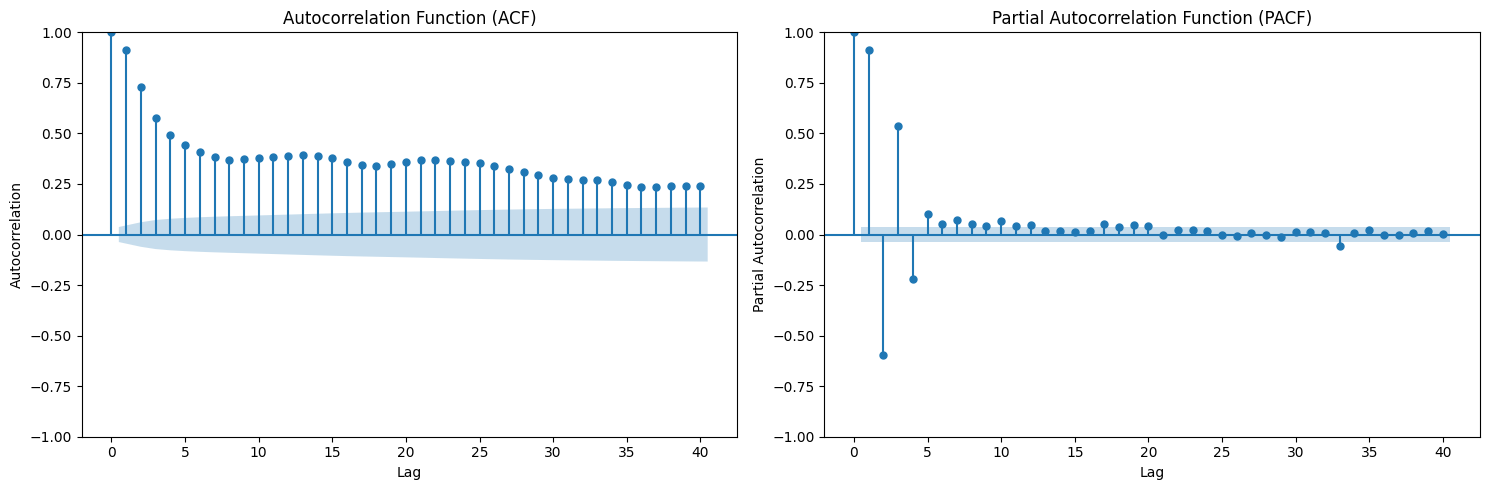

In [133]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(clean_cloudCover_series, lags=40, ax=ax[0])
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("Autocorrelation")
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(clean_cloudCover_series, lags=40, ax=ax[1])
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("Partial Autocorrelation")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [134]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistika: {result[0]}')
    print(f'p-reikšmė: {p_value}')
    print('Stacionari laiko eilutė' if p_value < 0.05 else 'Nestacionari laiko eilutė')


check_stationarity(clean_cloudCover_series_scaled)

ADF Statistika: -5.321051685928543
p-reikšmė: 4.9518144453002354e-06
Stacionari laiko eilutė


In [135]:
model_auto = Arima(
    order = None,  
    seasonal_order = None,
    seasonal = True,
    m = 7,
    ic = "aic",
    stepwise = True,
    trace = True
)

model_auto.fit(y=clean_cloudCover_series_scaled, suppress_warnings=True)

print("-" * 30)
print(f"Geriausi parinkti parametrai: {model_auto.best_params_}")


Fitting models using approximations...

 ARIMA(p,d,q)(P,D,Q)[m]                     : aic
 ------------------------------------------------
 ARIMA(2,0,2)(1,0,1)[7] with non-zero mean : 246.9808
 ARIMA(0,0,0) with non-zero mean : 7870.5952
 ARIMA(1,0,0)(1,0,0)[7] with non-zero mean : 2893.2596
 ARIMA(0,0,1)(0,0,1)[7] with non-zero mean : 4260.8772
 ARIMA(0,0,0) with zero mean     : 7868.5952
 ARIMA(2,0,2)(0,0,1)[7] with non-zero mean : 269.7786
 ARIMA(2,0,2)(1,0,0)[7] with non-zero mean : 269.7260
 ARIMA(2,0,2)(2,0,1)[7] with non-zero mean : 239.7943
 ARIMA(2,0,2)(2,0,1)[7] with zero mean     : 237.7972
 ARIMA(2,0,2)(1,0,1)[7] with zero mean     : 244.9833
 ARIMA(2,0,2)(2,0,0)[7] with zero mean     : 259.9625
 ARIMA(2,0,2)(2,0,2)[7] with zero mean     : 237.9305
 ARIMA(2,0,2)(1,0,0)[7] with zero mean     : 267.7290
 ARIMA(2,0,2)(1,0,2)[7] with zero mean     : 237.0845
 ARIMA(2,0,2)(1,0,2)[7] with non-zero mean : 239.0815
 ARIMA(2,0,2)(0,0,2)[7] with zero mean     : 261.4487
 ARIMA(2,0,

In [136]:
sarima = SARIMAX(scaler.fit_transform(agg_meteo_data_copy[['test_cloudCover']]),
                order=(3, 0, 1),
                seasonal_order=(1, 0, 2, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_results = sarima.fit(disp=False)
# agg_meteo_data_copy['sarima_cloudCover'] = agg_meteo_data_copy['test_cloudCover'].fillna(sarima_results.fittedvalues)
agg_meteo_data_copy['sarima_cloudCover'] = agg_meteo_data_copy['test_cloudCover'].fillna(pd.Series(scaler.inverse_transform(sarima_results.fittedvalues.reshape(-1, 1)).flatten(), index=agg_meteo_data_copy.index))
agg_meteo_data_copy['sarima_cloudCover'] = agg_meteo_data_copy['sarima_cloudCover'].clip(lower=0)

In [137]:
agg_meteo_data_copy['sarima_cloudCover'].isnull().sum()

np.int64(0)

Mašininio mokymosi algoritmo pritaikymas:

Pritaikysime palydovinius debesų rodiklius

In [138]:
sentinel_data = pd.read_csv("Sentinel_5p_data.csv", sep = ',')
sentinel_data['time'] = pd.to_datetime(sentinel_data['time'].astype(str).str[:10])
sentinel_data['observationTime'] = sentinel_data['time']
sentinel_data = sentinel_data.drop(columns = ['time'])
final_sentinel_data = sentinel_data[(sentinel_data["observationTime"].dt.date >= datetime.date(2018,7,1)) & (sentinel_data["observationTime"].dt.date <= datetime.date(2026,1,31))].sort_values(by='observationTime')
final_sentinel_data.head(5)

,Unnamed: 0,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density,observationTime
2804,2804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000063,0.000191,19223.482,NaN,NaN,NaN,NaN,2018-07-01
2805,2805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000062,0.000193,22057.926,NaN,NaN,NaN,NaN,2018-07-02
2806,2806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000009,0.000066,0.000196,22067.760,NaN,NaN,NaN,NaN,2018-07-03
0,0,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN,2018-07-04
1,1,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277,2018-07-05


In [139]:
sentinel_clouds_data = sentinel_data[['observationTime', 'cloud_fraction', 'cloud_top_pressure', 'cloud_top_height', 'cloud_base_pressure', 'cloud_base_height', 'cloud_optical_depth']]
sentinel_clouds_data.isnull().sum()

observationTime          0
cloud_fraction         211
cloud_top_pressure     316
cloud_top_height       317
cloud_base_pressure    316
cloud_base_height      317
cloud_optical_depth    317
dtype: int64

In [140]:
merged_meteo_sentinel_data = pd.merge(agg_meteo_data_copy, sentinel_clouds_data, on='observationTime', how='outer')
merged_meteo_sentinel_data.shape

(2814, 20)

In [141]:
merged_meteo_sentinel_data.head(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation,test_cloudCover,cloudCover_MA_12,cloudCover_MA_12_24,sarima_cloudCover,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth
0,2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-07-01,11.295833,10.933333,3.762500,13.9,356.0,89.375,1010.6375,72.791667,9.1,89.375,89.375,89.375,89.375,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-07-02,10.866667,10.429167,2.516667,7.0,327.0,91.500,1006.6625,94.000000,11.9,91.500,91.500,91.500,91.500,NaN,NaN,NaN,NaN,NaN,NaN


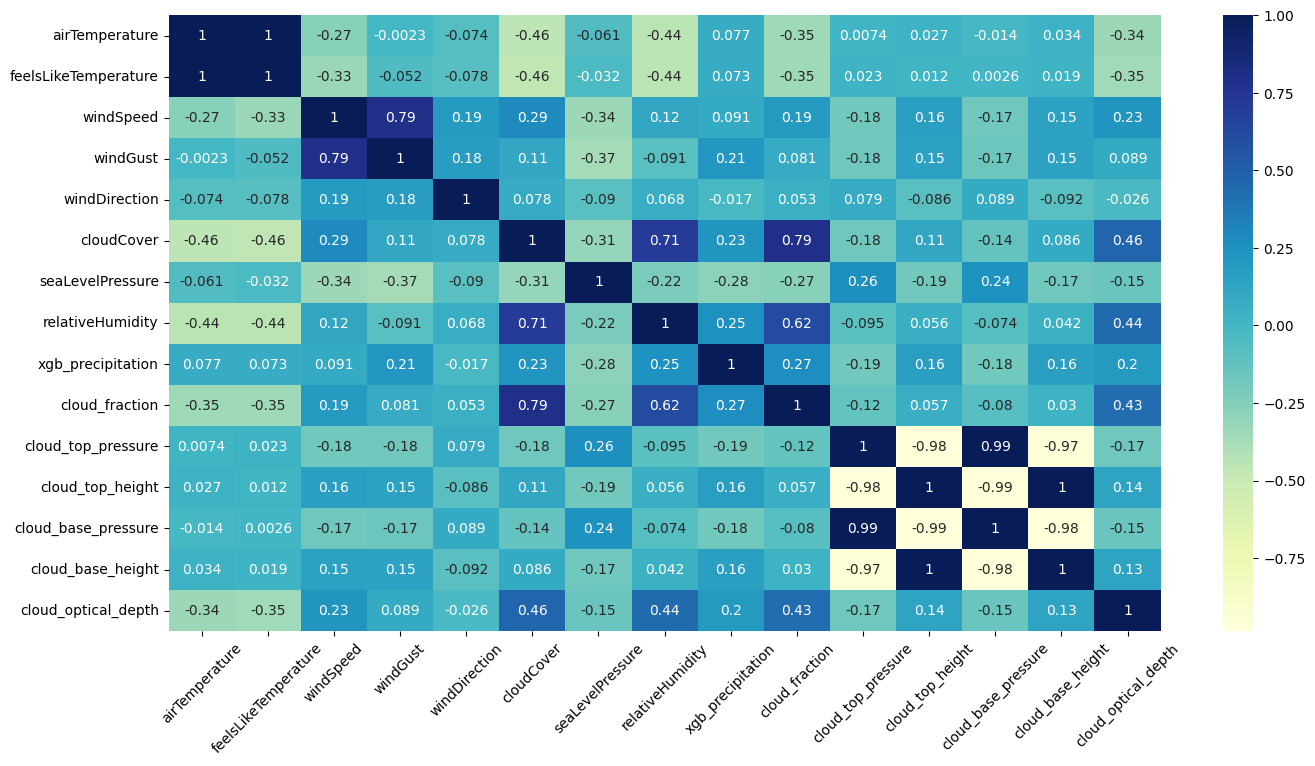

In [142]:
plt.figure(figsize=(16, 8))

cloud_cover_corr = merged_meteo_sentinel_data.drop(columns = ['cloudCover_MA_12', 'cloudCover_MA_12_24', 'sarima_cloudCover', 'test_cloudCover']).corr(numeric_only=True)

sb.heatmap(cloud_cover_corr, cmap="YlGnBu", annot=True)
plt.xticks(rotation=45)
plt.title("")
plt.show()

MICE metodas:

In [143]:
numeric_data = merged_meteo_sentinel_data.select_dtypes(include='number')
numeric_data = numeric_data.drop(columns=['cloudCover', 'cloudCover_MA_12', 'cloudCover_MA_12_24', 'sarima_cloudCover'])
numeric_data.head()

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,seaLevelPressure,relativeHumidity,xgb_precipitation,test_cloudCover,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11.295833,10.933333,3.762500,13.9,356.0,1010.6375,72.791667,9.1,89.375,NaN,NaN,NaN,NaN,NaN,NaN
4,10.866667,10.429167,2.516667,7.0,327.0,1006.6625,94.000000,11.9,91.500,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
numeric_data_scaled = pd.DataFrame(scaler.fit_transform(numeric_data), columns=numeric_data.columns, index=numeric_data.index)

In [145]:
imputer = IterativeImputer(random_state=123)
imputed_data = imputer.fit_transform(numeric_data_scaled)
meteo_imputed_mice = pd.DataFrame(scaler.inverse_transform(imputed_data), columns=numeric_data.columns, index=numeric_data.index)
merged_meteo_sentinel_data['mice_cloudCover'] = meteo_imputed_mice['test_cloudCover']
merged_meteo_sentinel_data['mice_cloudCover'] = merged_meteo_sentinel_data['mice_cloudCover'].clip(lower = 0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


XGBoost:

In [146]:
xgb = IterativeImputer(estimator=XGBRegressor(n_estimators=100, random_state=123), max_iter=10, random_state=123)
xgb_transformed = xgb.fit_transform(numeric_data_scaled)
imputed_df_xgb = pd.DataFrame(scaler.inverse_transform(xgb_transformed), columns=numeric_data.columns, index=numeric_data.index)
merged_meteo_sentinel_data['xgb_cloudCover'] = imputed_df_xgb['test_cloudCover']
merged_meteo_sentinel_data['xgb_cloudCover'] = merged_meteo_sentinel_data['xgb_cloudCover'].clip(lower = 0)

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Įrašymo metodų palyginimas

In [147]:
# pd.set_option('display.max_rows', 600)
# data_first_block[data_first_block['test_cloudCover'].isnull()]

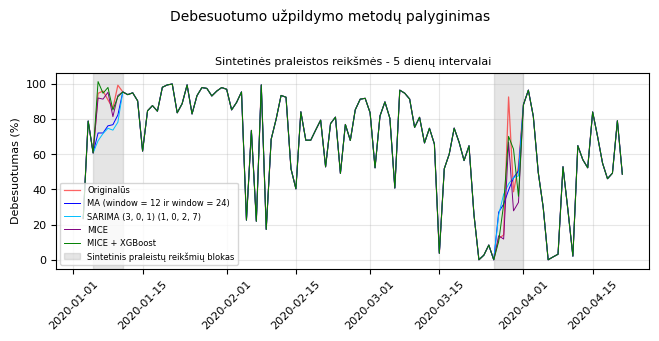

In [148]:
start = int(len(agg_meteo_data_copy) * 0.2)
data_first_block = merged_meteo_sentinel_data[start : start + 110]

width_inch = 17 / 2.54
height_inch = width_inch * 0.5

fig, ax1 = plt.subplots(figsize=(width_inch, height_inch))
ax1.plot(data_first_block['observationTime'], data_first_block['cloudCover'], label='Originalūs', color='red', linewidth=0.9, alpha=0.6)
ax1.plot(data_first_block['observationTime'], data_first_block['cloudCover_MA_12_24'], label='MA (window = 12 ir window = 24)', color='blue', linewidth=0.7)
ax1.plot(data_first_block['observationTime'], data_first_block['sarima_cloudCover'], label='SARIMA (3, 0, 1) (1, 0, 2, 7)', color='deepskyblue', linewidth=0.7)
ax1.plot(data_first_block['observationTime'], data_first_block['mice_cloudCover'], label='MICE', color='purple', linewidth=0.7)
ax1.plot(data_first_block['observationTime'], data_first_block['xgb_cloudCover'], label='MICE + XGBoost', color='green', linewidth=0.7)
ax1.axvspan('2020-01-05', '2020-01-11', 
            color='gray', alpha=0.2, label='Sintetinis praleistų reikšmių blokas')
ax1.axvspan('2020-03-26', '2020-04-01', 
            color='gray', alpha=0.2)
ax1.set_ylabel('Debesuotumas (%)', fontsize=8)
ax1.tick_params(axis='both', labelsize=8)
ax1.set_title('Sintetinės praleistos reikšmės - 5 dienų intervalai',  fontsize=8)
ax1.legend(fontsize=6, loc='lower left')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

fig.suptitle('Debesuotumo užpildymo metodų palyginimas', fontsize=10, y=1.005)

plt.savefig("algorithms_comparison_cloudCover.png", dpi=300, bbox_inches='tight')

plt.tight_layout() 
plt.show()

Metrikos:

In [149]:
synthetic_nan = merged_meteo_sentinel_data['test_cloudCover'].isna() & merged_meteo_sentinel_data['cloudCover'].notna()
cloudCover_true = merged_meteo_sentinel_data.loc[synthetic_nan, 'cloudCover']
cloudCover_ma = merged_meteo_sentinel_data.loc[synthetic_nan, 'cloudCover_MA_12_24']
cloudCover_sarima = merged_meteo_sentinel_data.loc[synthetic_nan, 'sarima_cloudCover']
cloudCover_mice = merged_meteo_sentinel_data.loc[synthetic_nan, 'mice_cloudCover']
cloudCover_xgb = merged_meteo_sentinel_data.loc[synthetic_nan, 'xgb_cloudCover']

# cloudCover_ma = cloudCover_ma.clip(lower=0)
# cloudCover_sarima = cloudCover_sarima.clip(lower=0)
# cloudCover_mice = cloudCover_mice.clip(lower=0)
# cloudCover_xgb = cloudCover_xgb.clip(lower=0)

results = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R^2'],
    'MA': [
        mean_absolute_error(cloudCover_true, cloudCover_ma),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_ma)),
        r2_score(cloudCover_true, cloudCover_ma)
    ],
    'SARIMA': [
        mean_absolute_error(cloudCover_true, cloudCover_sarima),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_sarima)),
        r2_score(cloudCover_true, cloudCover_sarima)
    ],
    'MICE': [
        mean_absolute_error(cloudCover_true, cloudCover_mice),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_mice)),
        r2_score(cloudCover_true, cloudCover_mice)
    ],
    'MICE + XGBoost': [
        mean_absolute_error(cloudCover_true, cloudCover_xgb),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_xgb)),
        r2_score(cloudCover_true, cloudCover_xgb)
    ]
})

print(results.round(4))

  Metrika       MA   SARIMA     MICE  MICE + XGBoost
0     MAE  22.5272  23.2398  13.0940         11.4399
1    RMSE  30.1462  29.1683  16.3589         14.8731
2     R^2   0.1273   0.1830   0.7430          0.7876


Debesuotumo praleistų reikšmių įrašymui naudosime XGBoost metodą

In [150]:
merged_meteo_sentinel_data = pd.merge(final_agg_meteo_data, sentinel_clouds_data, on='observationTime', how='outer')
merged_meteo_sentinel_data.head(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth
0,2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-07-01,11.295833,10.933333,3.762500,13.9,356.0,89.375,1010.6375,72.791667,9.1,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-07-02,10.866667,10.429167,2.516667,7.0,327.0,91.500,1006.6625,94.000000,11.9,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
numeric_data = merged_meteo_sentinel_data.select_dtypes(include='number')

In [152]:
xgb = IterativeImputer(estimator=XGBRegressor(n_estimators=100, random_state=123), max_iter=10, random_state=123)
xgb_transformed = xgb.fit_transform(numeric_data)
imputed_df_xgb = pd.DataFrame(xgb_transformed, columns=numeric_data.columns, index=numeric_data.index)
merged_meteo_sentinel_data['xgb_cloudCover'] = imputed_df_xgb['cloudCover']

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [153]:
agg_meteo_data_cloudCover = final_agg_meteo_data.merge(merged_meteo_sentinel_data[['observationTime', 'xgb_cloudCover']], on='observationTime', how='left')
agg_meteo_data_cloudCover.head(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover
0,2018-07-01,11.295833,10.933333,3.762500,13.9,356.0,89.375000,1010.637500,72.791667,9.1,89.375000
1,2018-07-02,10.866667,10.429167,2.516667,7.0,327.0,91.500000,1006.662500,94.000000,11.9,91.500000
2,2018-07-03,13.387500,13.387500,2.537500,8.3,271.0,89.375000,1008.454167,90.041667,10.0,89.375000
3,2018-07-04,13.591667,13.591667,2.358333,8.7,288.0,88.333333,1009.237500,88.291667,13.9,88.333333
4,2018-07-05,16.291667,16.291667,1.283333,6.1,293.0,66.000000,1008.079167,70.208333,0.0,66.000000


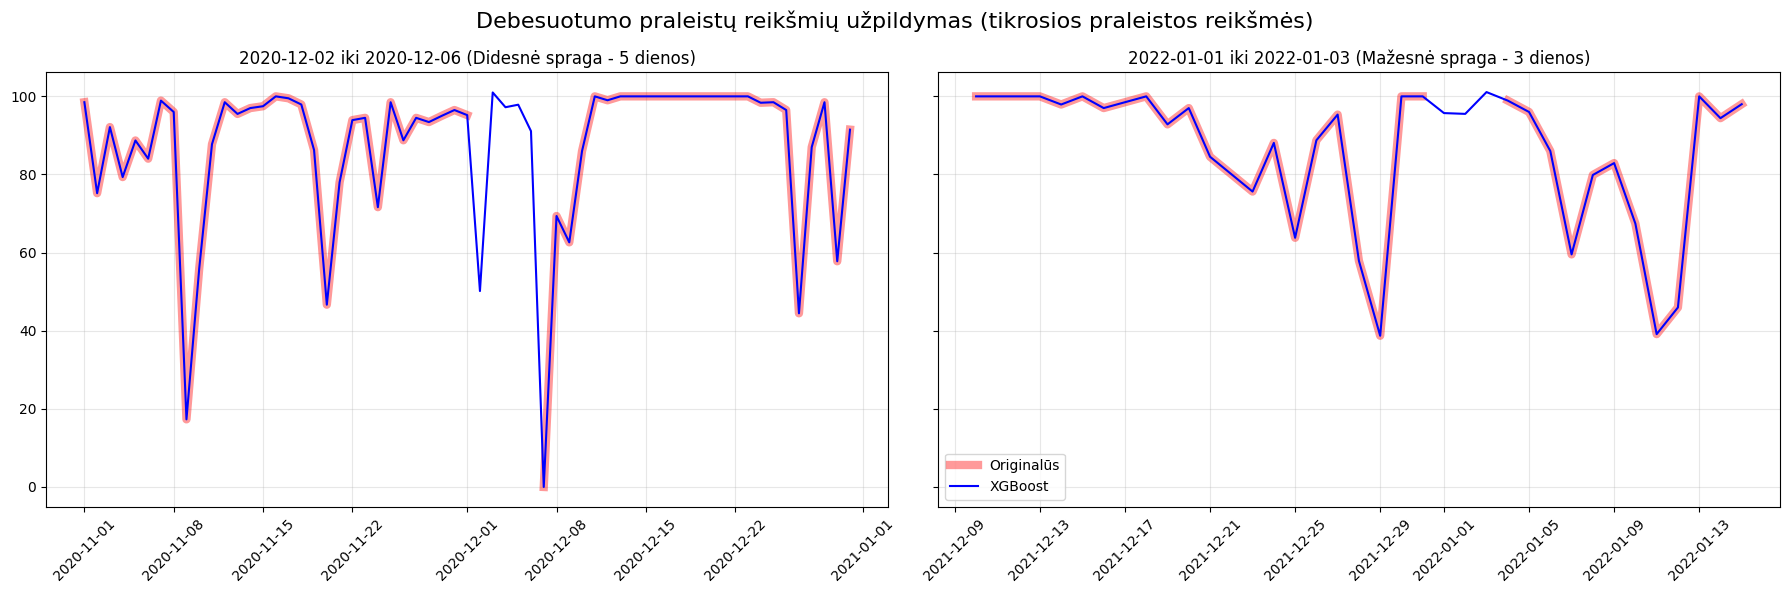

In [154]:
time_mask1 = (agg_meteo_data_cloudCover['observationTime'] >= '2020-11-01') & (agg_meteo_data_cloudCover['observationTime'] <= '2020-12-31')
time_mask2 = (agg_meteo_data_cloudCover['observationTime'] >= '2021-12-10') & (agg_meteo_data_cloudCover['observationTime'] <= '2022-01-15')
filtered_data1 = agg_meteo_data_cloudCover[time_mask1]
filtered_data2 = agg_meteo_data_cloudCover[time_mask2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

ax1.plot(filtered_data1['observationTime'], filtered_data1['cloudCover'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax1.plot(filtered_data1['observationTime'], filtered_data1['xgb_cloudCover'], label='XGBoost', color='blue', linewidth=1.5)
ax1.set_title('2020-12-02 iki 2020-12-06 (Didesnė spraga - 5 dienos)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.plot(filtered_data2['observationTime'], filtered_data2['cloudCover'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax2.plot(filtered_data2['observationTime'], filtered_data2['xgb_cloudCover'], label='XGBoost', color='blue', linewidth=1.5)
ax2.set_title('2022-01-01 iki 2022-01-03 (Mažesnė spraga - 3 dienos)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Debesuotumo praleistų reikšmių užpildymas (tikrosios praleistos reikšmės)', fontsize=16)
plt.tight_layout()
plt.show()

Kadangi keturiuose požymiuose yra po vieną praleistą reikšmę, praleistų reikšmių užpildymui taikysime slankųjį vidurkį

In [155]:
agg_meteo_data_cloudCover = agg_meteo_data_cloudCover.drop(columns=['cloudCover'])
agg_meteo_data_cloudCover.isnull().sum()

observationTime         0
airTemperature          0
feelsLikeTemperature    1
windSpeed               1
windGust                1
windDirection           1
seaLevelPressure        0
relativeHumidity        0
xgb_precipitation       0
xgb_cloudCover          0
dtype: int64

In [156]:
final_meteo_data = agg_meteo_data_cloudCover.copy()
cols_to_fix = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection']

for col in cols_to_fix:
    smooth = final_meteo_data[col].rolling(window=10, min_periods=2, center=True).mean()
    final_meteo_data[f'{col}_fixed'] = final_meteo_data[col].fillna(smooth)

final_meteo_data = final_meteo_data.drop(columns = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection'])
final_meteo_data.head(5)

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,2018-07-01,11.295833,1010.637500,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0
1,2018-07-02,10.866667,1006.662500,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0
2,2018-07-03,13.387500,1008.454167,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0
3,2018-07-04,13.591667,1009.237500,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0
4,2018-07-05,16.291667,1008.079167,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0


In [157]:
final_meteo_data.tail(5)

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
2767,2026-01-27,-2.200000,1005.416667,95.625000,3.8,100.000000,-4.162500,1.600000,4.6,70.0
2768,2026-01-28,-5.012500,1002.875000,91.916667,6.0,100.000000,-8.941667,2.495833,7.5,33.0
2769,2026-01-29,-9.604167,1009.787500,87.000000,0.0,81.291667,-14.795833,2.812500,8.3,35.0
2770,2026-01-30,-13.600000,1019.316667,78.833333,0.0,0.541667,-18.804167,2.354167,8.7,42.0
2771,2026-01-31,-15.366667,1025.933333,76.666667,0.0,0.000000,-19.350000,1.720833,4.7,30.0


In [158]:
final_meteo_data.isnull().sum()

observationTime               0
airTemperature                0
seaLevelPressure              0
relativeHumidity              0
xgb_precipitation             0
xgb_cloudCover                0
feelsLikeTemperature_fixed    0
windSpeed_fixed               0
windGust_fixed                0
windDirection_fixed           0
dtype: int64

Duomenų įrašymas

In [159]:
final_meteo_data.shape

(2772, 10)

In [160]:
final_meteo_data.to_csv('Vilnius_meteo_data_final_2018_2026.csv', index=False, encoding='utf-8-sig')